Finite-horizon stochastic execution, c=0.03, tau=0.025
t= 1: lower_b=0.171, upper_b=0.829, lower_L=-0.686, upper_L=0.686
t= 2: lower_b=0.174, upper_b=0.826, lower_L=-0.676, upper_L=0.676
t= 3: lower_b=0.177, upper_b=0.823, lower_L=-0.667, upper_L=0.667
t= 4: lower_b=0.181, upper_b=0.819, lower_L=-0.656, upper_L=0.656
t= 5: lower_b=0.187, upper_b=0.813, lower_L=-0.638, upper_L=0.638
t= 6: lower_b=0.197, upper_b=0.803, lower_L=-0.610, upper_L=0.610
t= 7: lower_b=0.213, upper_b=0.787, lower_L=-0.568, upper_L=0.568
t= 8: lower_b=0.242, upper_b=0.758, lower_L=-0.496, upper_L=0.496
t= 9: lower_b=0.301, upper_b=0.699, lower_L=-0.366, upper_L=0.366
t=10: lower_b=0.500, upper_b=0.500, lower_L=0.000, upper_L=0.000


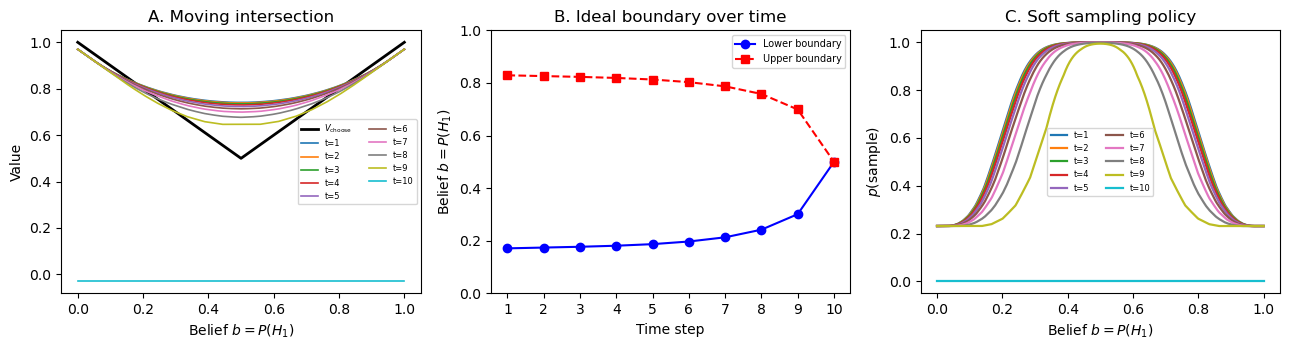

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# Finite-horizon stochastic execution observer
# Perfect evidence representation and integration
# Softmax/Gumbel execution noise
# ============================================================

# -----------------------------
# Parameters
# -----------------------------

c = 0.03
tau_exec = 0.025

R_correct = 1.0
R_wrong = 0.0

T_deadline = 11
max_timestep = 10

n_trials = 5 * 10**4
rng = np.random.default_rng(1)

# ============================================================
# 1. Define 16 stimulus types and pA / pB
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio: log10 P(x|H1) / P(x|H0)
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Belief grid
# ============================================================

N_b = 1001
b_grid = np.linspace(0, 1, N_b)

eps = 1e-12

log_odds_grid = np.log10(
    np.clip(b_grid, eps, 1 - eps)
    /
    np.clip(1 - b_grid, eps, 1 - eps)
)

# Stop action values before deadline
Q0 = (1 - b_grid) * R_correct + b_grid * R_wrong
Q1 = b_grid * R_correct + (1 - b_grid) * R_wrong
V_choose = np.maximum(Q0, Q1)

# ============================================================
# 3. Helper: softmax over three actions
# ============================================================

def softmax_3actions(Q0, Q1, QW, tau):
    """
    Return softmax execution probabilities for:
        action 0 = choose H0
        action 1 = choose H1
        action 2 = sample / wait
    """
    Q_stack = np.vstack([Q0, Q1, QW]) / tau
    Q_stack = Q_stack - np.max(Q_stack, axis=0, keepdims=True)
    exp_Q = np.exp(Q_stack)
    probs = exp_Q / np.sum(exp_Q, axis=0, keepdims=True)
    return probs

# ============================================================
# 4. Finite-horizon backward induction
#    V[11, :] = 0 everywhere
# ============================================================

V = np.zeros((T_deadline + 1, N_b))
Q_wait_all = np.zeros((T_deadline + 1, N_b))

lower_b = np.full(T_deadline + 1, np.nan)
upper_b = np.full(T_deadline + 1, np.nan)

lower_log_boundary = np.full(T_deadline + 1, np.nan)
upper_log_boundary = np.full(T_deadline + 1, np.nan)

# Terminal deadline:
# at t = 11, choosing gives zero reward everywhere.
V[T_deadline, :] = 0.0

# Backward induction: t = 10, ..., 1
for t in range(T_deadline - 1, 0, -1):

    Q_wait = np.zeros_like(b_grid)

    for j, b in enumerate(b_grid):

        expected_future_value = 0.0

        for i in range(len(pA)):

            q_i = b * pB[i] + (1 - b) * pA[i]

            if q_i > 0:
                b_next = (b * pB[i]) / q_i

                expected_future_value += q_i * np.interp(
                    b_next,
                    b_grid,
                    V[t + 1, :]
                )

        Q_wait[j] = -c + expected_future_value

    Q_wait_all[t, :] = Q_wait

    # Ideal value backup.
    # Softness is applied later at execution stage.
    V[t, :] = np.maximum(V_choose, Q_wait)

    continue_region = Q_wait > V_choose

    if np.any(continue_region):
        lower_b[t] = b_grid[continue_region][0]
        upper_b[t] = b_grid[continue_region][-1]
    else:
        lower_b[t] = 0.5
        upper_b[t] = 0.5

    lower_log_boundary[t] = np.log10(
        np.clip(lower_b[t], eps, 1 - eps)
        /
        np.clip(1 - lower_b[t], eps, 1 - eps)
    )

    upper_log_boundary[t] = np.log10(
        np.clip(upper_b[t], eps, 1 - eps)
        /
        np.clip(1 - upper_b[t], eps, 1 - eps)
    )

print(f"Finite-horizon stochastic execution, c={c}, tau={tau_exec}")
for t in range(1, max_timestep + 1):
    print(
        f"t={t:2d}: "
        f"lower_b={lower_b[t]:.3f}, upper_b={upper_b[t]:.3f}, "
        f"lower_L={lower_log_boundary[t]:.3f}, "
        f"upper_L={upper_log_boundary[t]:.3f}"
    )

# ============================================================
# 5. Soft execution policies over time
# ============================================================

p_choose0_all = np.zeros((T_deadline + 1, N_b))
p_choose1_all = np.zeros((T_deadline + 1, N_b))
p_sample_all = np.zeros((T_deadline + 1, N_b))

for t in range(1, max_timestep + 1):

    probs_t = softmax_3actions(
        Q0,
        Q1,
        Q_wait_all[t, :],
        tau_exec
    )

    p_choose0_all[t, :] = probs_t[0, :]
    p_choose1_all[t, :] = probs_t[1, :]
    p_sample_all[t, :] = probs_t[2, :]

# ============================================================
# 6. Panel A/B/C summary figure
#    A: moving intersections of V_choose and V_wait
#    B: ideal hard boundaries over time
#    C: soft p(sample) over belief
# ============================================================

time_colors = plt.cm.tab10(np.arange(max_timestep))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axA, axB, axC = axes

# -----------------------------
# Panel A: V_choose and Q_wait intersections
# -----------------------------

axA.plot(
    b_grid,
    V_choose,
    color="black",
    linewidth=2,
    label=r"$V_{\mathrm{choose}}$"
)

for t in range(1, max_timestep + 1):
    axA.plot(
        b_grid,
        Q_wait_all[t, :],
        color=time_colors[t - 1],
        linewidth=1.2,
        label=f"t={t}"
    )

axA.set_xlabel(r"Belief $b=P(H_1)$")
axA.set_ylabel("Value")
axA.set_title("A. Moving intersection")
axA.legend(fontsize=6, ncol=2, frameon=True)

# -----------------------------
# Panel B: hard ideal boundaries over time
# -----------------------------

t_grid = np.arange(1, max_timestep + 1)

axB.plot(
    t_grid,
    lower_b[1:max_timestep + 1],
    marker="o",
    color="blue",
    label="Lower boundary"
)

axB.plot(
    t_grid,
    upper_b[1:max_timestep + 1],
    marker="s",
    linestyle="--",
    color="red",
    label="Upper boundary"
)

axB.set_xlabel("Time step")
axB.set_ylabel(r"Belief $b=P(H_1)$")
axB.set_ylim(0, 1)
axB.set_xticks(t_grid)
axB.set_title("B. Ideal boundary over time")
axB.legend(fontsize=7, frameon=True)

# -----------------------------
# Panel C: soft p(sample) over belief
# -----------------------------

for t in range(1, max_timestep + 1):
    axC.plot(
        b_grid,
        p_sample_all[t, :],
        color=time_colors[t - 1],
        linewidth=1.6,
        label=f"t={t}"
    )

axC.set_xlabel(r"Belief $b=P(H_1)$")
axC.set_ylabel(r"$p(\mathrm{sample})$")
axC.set_ylim(-0.05, 1.05)
axC.set_title("C. Soft sampling policy")
axC.legend(fontsize=6, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

   trial  true_H  time_step  stim_idx  evidence_sum    belief  action  \
0      0       0          1        12           0.5  0.759747       1   
1      1       1          1        14           0.7  0.833662       1   
2      2       1          1        12           0.5  0.759747       2   
3      2       1          2         9           0.7  0.833662       1   
4      3       0          1         8           0.1  0.557312       2   

      p_choose0  p_choose1  p_sample  
0  1.938616e-10   0.205128  0.794872  
1  1.325805e-12   0.518921  0.481079  
2  1.938616e-10   0.205128  0.794872  
3  1.348623e-12   0.527852  0.472148  
4  5.980123e-06   0.000586  0.999408  
action
2    145002
1     25022
0     24978
Name: count, dtype: int64


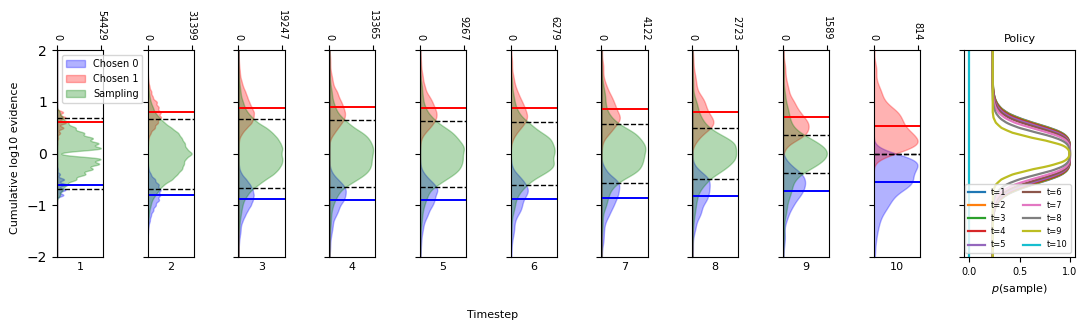

In [2]:
# ============================================================
# 7. Simulate 5*10^4 trials using soft execution policy
# ============================================================

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)
    evidence_sum = 0.0

    for t in range(1, max_timestep + 1):

        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        evidence_sum += target_log_ratios[stim_idx]

        b = 1.0 / (1.0 + 10.0 ** (-evidence_sum))

        q0_t = np.interp(b, b_grid, Q0)
        q1_t = np.interp(b, b_grid, Q1)
        qw_t = np.interp(b, b_grid, Q_wait_all[t, :])

        probs_t = softmax_3actions(
            np.array([q0_t]),
            np.array([q1_t]),
            np.array([qw_t]),
            tau_exec
        ).flatten()

        action = rng.choice([0, 1, 2], p=probs_t)

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "evidence_sum": evidence_sum,
            "belief": b,
            "action": action,
            "p_choose0": probs_t[0],
            "p_choose1": probs_t[1],
            "p_sample": probs_t[2]
        })

        # Stop trial after executed choice.
        # If action == 2 at t=10, the trial simply reaches deadline.
        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

# ============================================================
# 8. Distribution plot + soft boundaries + attached policy curves
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green"
}

labels = {
    0: "Chosen 0",
    1: "Chosen 1",
    2: "Sampling"
}

fig, axes = plt.subplots(
    1,
    max_timestep + 1,
    figsize=(11.5, 3.4),
    sharey=True,
    gridspec_kw={"width_ratios": [1] * max_timestep + [2.4]}
)

dist_axes = axes[:-1]
policy_ax = axes[-1]

y_min = -2.0
y_max = 2.0
y_grid = np.linspace(y_min, y_max, 500)

# ------------------------------------------------------------
# Left panels: empirical distributions over cumulative log10 odds
# ------------------------------------------------------------

for t in range(1, max_timestep + 1):

    ax = dist_axes[t - 1]
    timestep_data = df_sim[df_sim["time_step"] == t]

    max_density = 0.0
    """
    # Soft boundary shadow from p(sample) at this time step
    p_sample_y = np.interp(
        y_grid,
        log_odds_grid,
        p_sample_all[t, :]
    )
    
    for k in range(len(y_grid) - 1):
        alpha_k = 0.30 * p_sample_y[k]
        if alpha_k > 0.003:
            ax.axhspan(
                y_grid[k],
                y_grid[k + 1],
                color="gray",
                alpha=alpha_k,
                linewidth=0
            )
    """
    for action in [0, 1, 2]:

        action_data = timestep_data[timestep_data["action"] == action]

        if action_data.empty:
            continue

        ev = action_data["evidence_sum"].to_numpy()

        if len(ev) < 3 or np.std(ev) == 0:
            continue

        kde = gaussian_kde(ev)
        density = kde(y_grid)

        density_scaled = density * len(ev)
        max_density = max(max_density, density_scaled.max())

        ax.fill_betweenx(
            y_grid,
            0,
            density_scaled,
            color=colors[action],
            alpha=0.3,
            label=labels[action] if t == 1 else None
        )

        if action in [0, 1]:
            mean_ev = np.mean(ev)
            ax.axhline(
                mean_ev,
                color=colors[action],
                linewidth=1.4
            )

    # Legend after fill_betweenx calls
    if t == 1:
        ax.legend(loc="upper left", fontsize=7, frameon=True)

    # Ideal hard boundaries = 50% / indifference points
    ax.axhline(
        lower_log_boundary[t],
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        upper_log_boundary[t],
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_ylim(y_min, y_max)

    if max_density > 0:
        ax.set_xlim(0, max_density * 1.05)
        ax.set_xticks([0, int(max_density)])
    else:
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 1])

    ax.xaxis.set_ticks_position("top")
    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        labelbottom=False
    )

    ax.set_xticklabels(
        [str(int(x)) for x in ax.get_xticks()],
        rotation=270,
        fontsize=7
    )

    ax.set_xlabel(str(t), fontsize=8)

# ------------------------------------------------------------
# Right panel: p(sample) soft policy curves
# ------------------------------------------------------------

for t in range(1, max_timestep + 1):

    p_sample_y = np.interp(
        y_grid,
        log_odds_grid,
        p_sample_all[t, :]
    )

    policy_ax.plot(
        p_sample_y,
        y_grid,
        color=time_colors[t - 1],
        linewidth=1.6,
        label=f"t={t}"
    )

policy_ax.set_xlim(-0.05, 1.05)
policy_ax.set_xticks([0, 0.5, 1.0])
policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
policy_ax.set_title("Policy", fontsize=8)
policy_ax.tick_params(axis="x", labelsize=7)

policy_ax.legend(
    loc="lower right",
    fontsize=6,
    ncol=2,
    frameon=True
)

# Shared labels
fig.text(0.48, 0.03, "Timestep", ha="center", fontsize=8)

fig.text(
    0.06,
    0.5,
    "Cumulative log10 evidence",
    va="center",
    rotation="vertical",
    fontsize=8
)

for ax in dist_axes:
    ax.label_outer()

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
plt.show()